In [12]:
from utils import *
import statsmodels.formula.api as smf


<h1 align='center'> Affiliation and power tendencies </h1>

## Samples differ on average

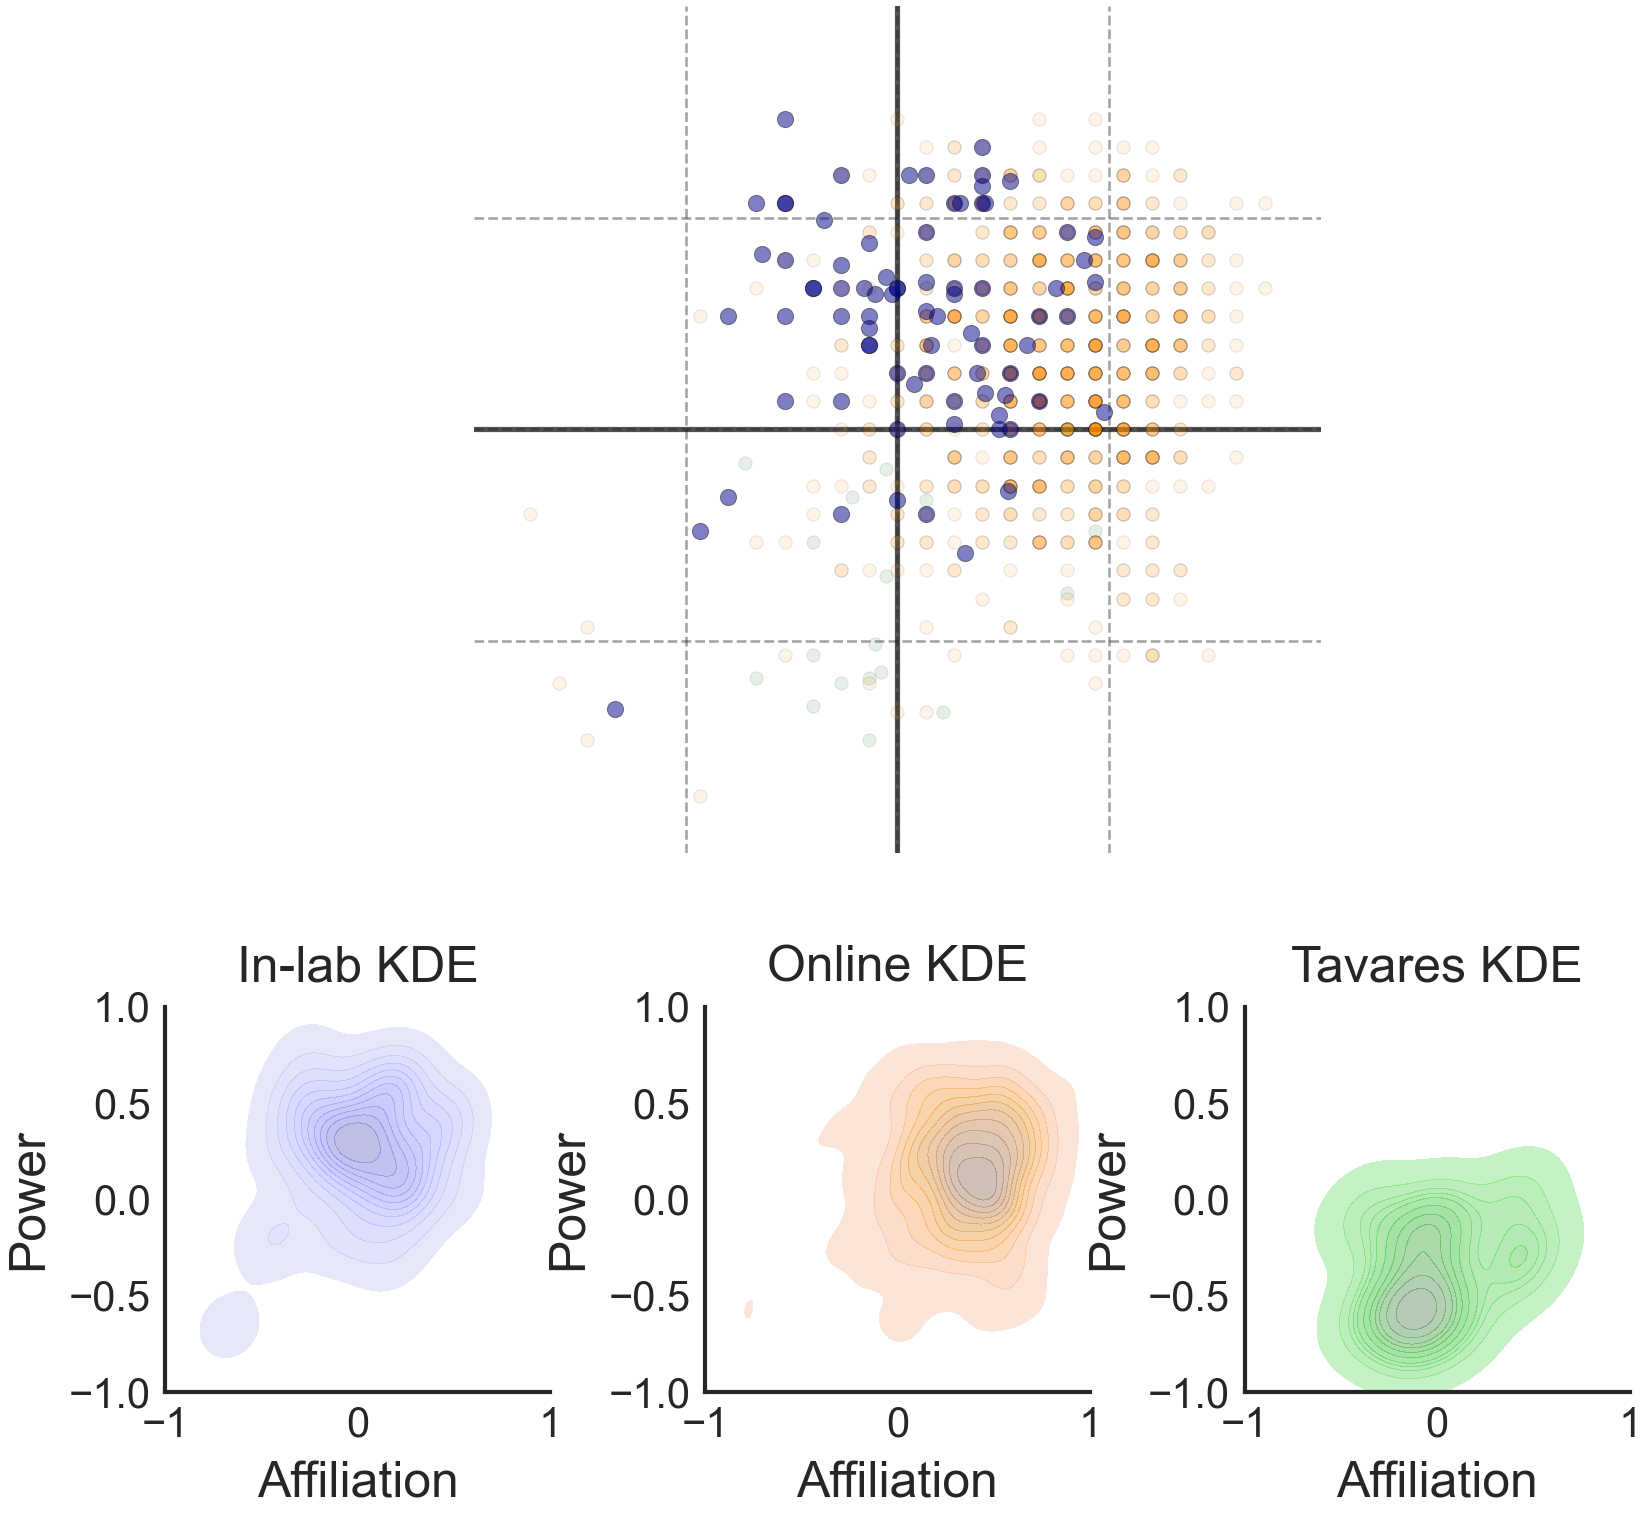

In [13]:
def scatter_with_kde(
    ax_scatter,
    ax_kde,
    df,
    *,
    x,
    y,
    color,
    alpha_scatter=0.25,
    s=12,
    edgecolor="k",
    linewidth=0.25,
    kde_fill=True,
    kde_levels=12,
    kde_thresh=0.02,
    kde_alpha=0.35,
    lims=(-1, 1),
):
    """Overlay a scatter on `ax_scatter` and draw a 2D KDE for the same data on `ax_kde`."""
    # ---- scatter (main)
    sns.scatterplot(
        x=x, y=y, data=df,
        alpha=alpha_scatter, s=s,
        color=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        ax=ax_scatter,
    )

    # ---- kde (below)
    sns.kdeplot(
        x=df[x], y=df[y],
        ax=ax_kde,
        fill=kde_fill,
        levels=kde_levels,
        thresh=kde_thresh,
        alpha=kde_alpha,
        color=color,
    )

    # ---- keep consistent "social space" framing
    for ax in (ax_scatter, ax_kde):
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    ax_kde.set_xlabel("Affiliation")
    ax_kde.set_ylabel("Power")


x = 'affil_mean_mean'
y = 'power_mean_mean'

fig = plt.figure(figsize=(6.5, 6.0))
gs = fig.add_gridspec(
    nrows=2, ncols=3,
    height_ratios=(2.2, 1.0),
    hspace=0.25, wspace=0.25
)

ax_scatter = fig.add_subplot(gs[0, :])
ax_kde_inlab   = fig.add_subplot(gs[1, 0])
ax_kde_online  = fig.add_subplot(gs[1, 1])
ax_kde_tavares = fig.add_subplot(gs[1, 2])

# main social space frame (your helper)
plot_social_space(ax_scatter)

# per-sample scatter + KDE
scatter_with_kde(
    ax_scatter, ax_kde_online, data_online,
    x=x, y=y,    
    color=sample_colors[1],
    alpha_scatter=0.10, s=10,
)
scatter_with_kde(
    ax_scatter, ax_kde_tavares, data_tavares,
    x=x, y=y,    
    color=sample_colors[2],
    alpha_scatter=0.10, s=10,
)
scatter_with_kde(
    ax_scatter, ax_kde_inlab, data,
    x=x, y=y,
    color=sample_colors[0],
    alpha_scatter=0.50, s=15,
)

# labels / titles for the KDE row
ax_kde_inlab.set_title("In-lab KDE")
ax_kde_online.set_title("Online KDE")
ax_kde_tavares.set_title("Tavares KDE")

# keep the top axis labels handled by plot_social_space; remove redundant labels
ax_scatter.set_xlabel("")
ax_scatter.set_ylabel("")

plt.tight_layout()
plt.show()


In [23]:
# barstrip_samples(data, 
#                  data_online=data_online, 
#                  data_tavares=data_tavares, 
#                  x=['affil_mean_mean', 'power_mean_mean']);

## We replicated the affiliation and power effects on social avoidance

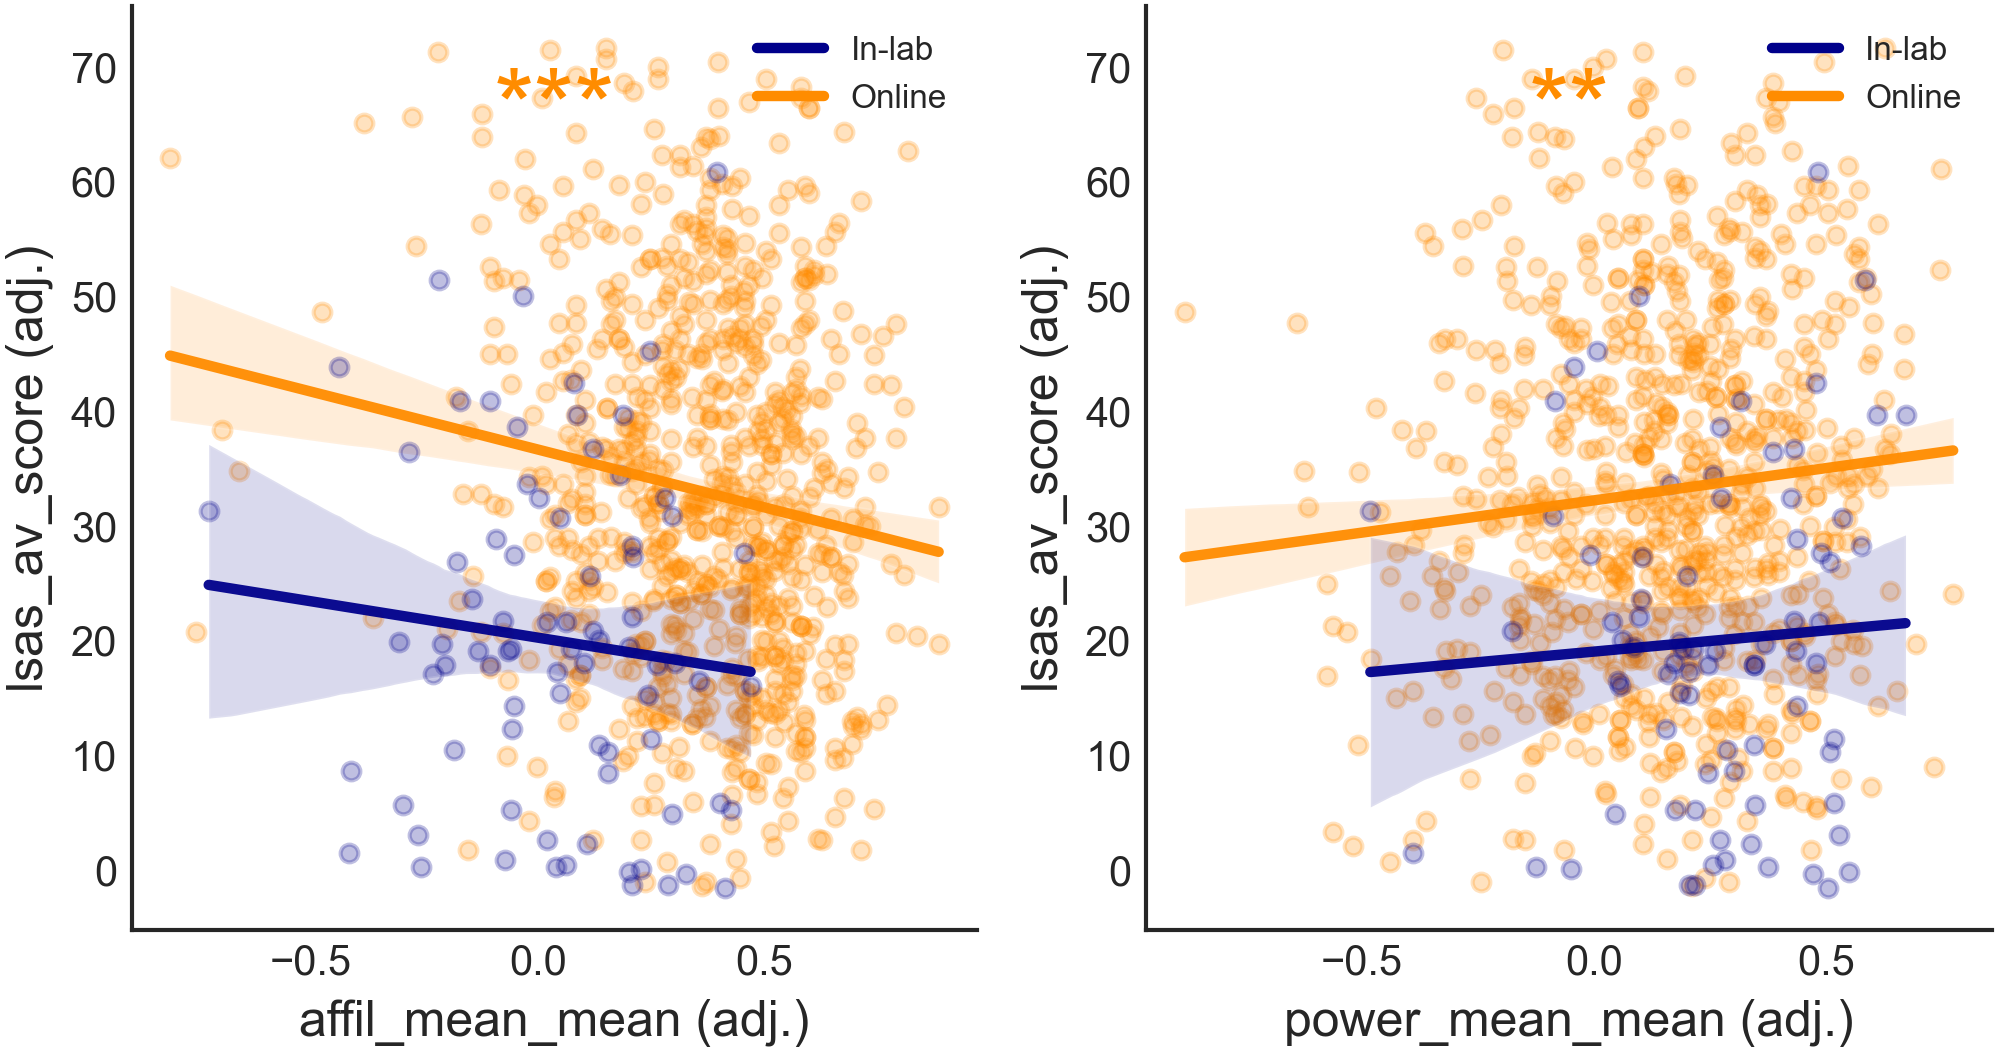

In [15]:
covariates = ['memory_mean']

fig, axs = plt.subplots(1,2, figsize=(8, 4))
ax = axs[0]
regplot_samples(data, data_online=data_online, x='affil_mean_mean', y='lsas_av_score', 
                covariates=covariates, tail='less', ax=ax)

ax = axs[1]
regplot_samples(data, data_online=data_online, x='power_mean_mean', y='lsas_av_score', 
                covariates=covariates, tail='greater', ax=ax);

### pattern is consistent with underpowered replication

In [16]:
data["sample"] = "inlab"
data_online["sample"] = "online"
df_all = pd.concat(
    [data, data_online],
    ignore_index=True,
    sort=False
)

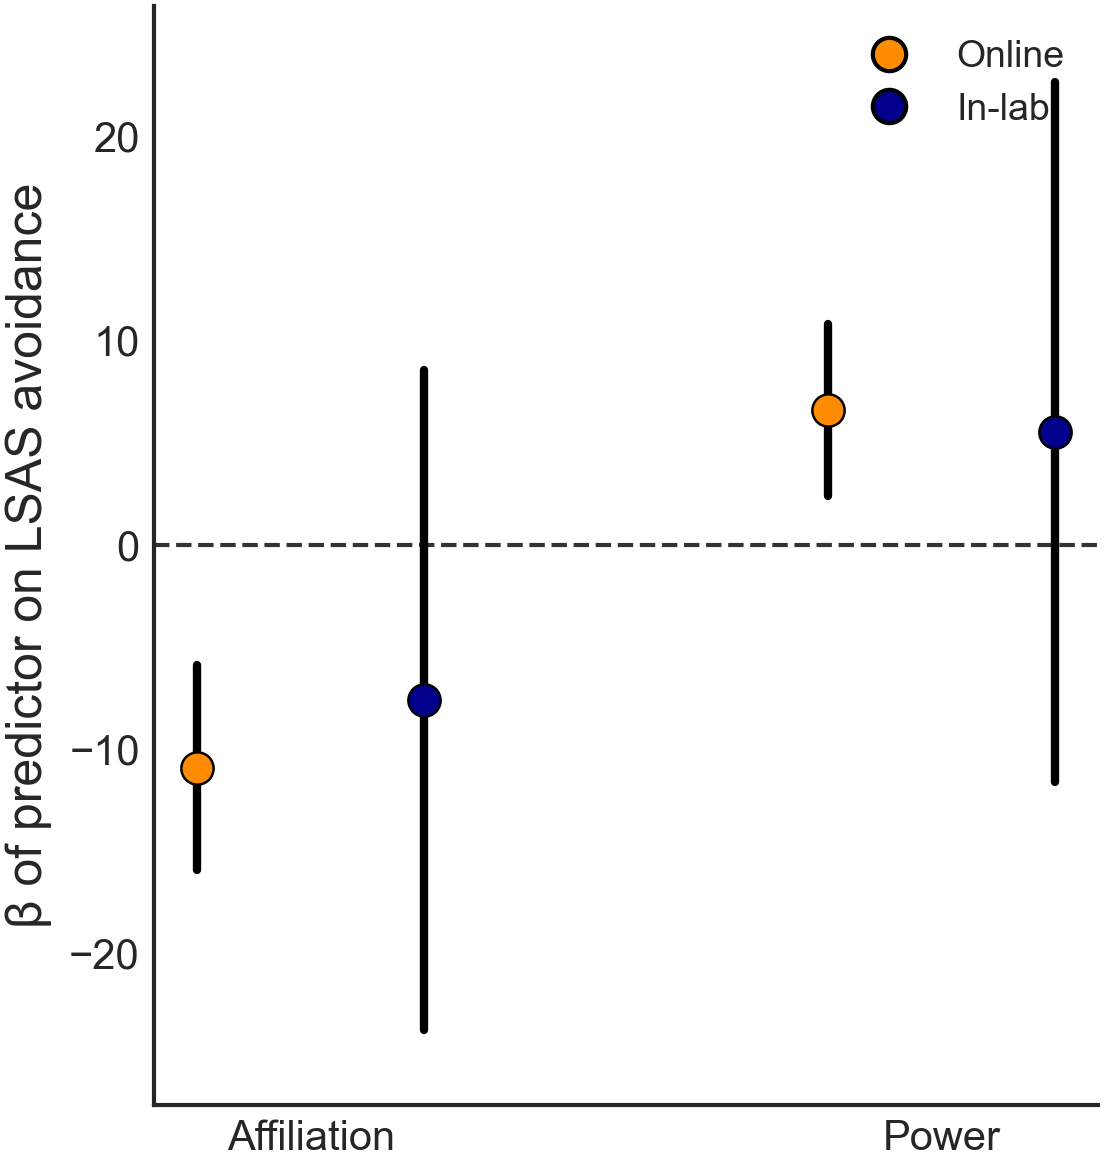

In [24]:
def fit_within_sample_and_extract(
    df,
    *,
    sample_value,
    outcome="lsas_av_score",
    predictors=("affil_mean_mean", "power_mean_mean"),
    covariates=("memory_mean",),
    cov_type="HC3",
):
    """
    Fit within-sample: outcome ~ predictors + covariates
    Return a tidy table with beta and 95% CI for each predictor.
    """
    d = df[df["sample"] == sample_value].copy()

    rhs = " + ".join([*predictors, *covariates]) if covariates else " + ".join(predictors)
    formula = f"{outcome} ~ {rhs}"

    m = smf.ols(formula, data=d).fit(cov_type=cov_type)

    rows = []
    for pred in predictors:
        beta = float(m.params[pred])
        lo, hi = m.conf_int().loc[pred].to_list()
        rows.append(dict(sample=sample_value, predictor=pred, beta=beta, ci_low=float(lo), ci_high=float(hi)))

    return pd.DataFrame(rows), m

def plot_betas_with_cis(
    plot_df,
    *,
    measure_order=("Affiliation", "Power"),
    sample_order=("Online", "In-lab"),
    figsize=(4, 4.2),
    point_size=60,
    ci_lw=2.0,
    dodge=0.18,
    ylim=None,
    title="",
    ylabel="β of predictor on LSAS avoidance",
):
    """
    plot_df must have columns: measure, sample, beta, ci_low, ci_high
    """
    df = plot_df.copy()

    # enforce ordering
    df["measure"] = pd.Categorical(df["measure"], categories=list(measure_order), ordered=True)
    df["sample"]  = pd.Categorical(df["sample"],  categories=list(sample_order),  ordered=True)
    df = df.sort_values(["measure", "sample"])

    # x positions
    x_base = {m: i for i, m in enumerate(measure_order)}
    x_offsets = np.linspace(-dodge, dodge, num=len(sample_order))
    off = {s: x_offsets[i] for i, s in enumerate(sample_order)}

    # basic colors (match your palette if you want)
    colors = {
        "Online":  "darkorange",
        "In-lab":  "darkblue",
    }

    fig, ax = plt.subplots(figsize=figsize)

    # draw points + CI bars
    for _, r in df.iterrows():
        x = x_base[str(r["measure"])] + off[str(r["sample"])]
        y = float(r["beta"])
        lo = float(r["ci_low"])
        hi = float(r["ci_high"])

        ax.plot([x, x], [lo, hi], color="black", lw=ci_lw, zorder=2)
        ax.scatter([x], [y], s=point_size, color=colors.get(str(r["sample"]), "gray"),
                   edgecolor="black", linewidth=0.6, zorder=3)

    # cosmetics
    ax.axhline(0, color="black", lw=1, linestyle="--", alpha=0.8, zorder=1)
    ax.set_xticks([x_base[m] for m in measure_order])
    ax.set_xticklabels(measure_order)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # y-limits
    if ylim is None:
        lo = np.nanmin(df["ci_low"].to_numpy(float))
        hi = np.nanmax(df["ci_high"].to_numpy(float))
        pad = 0.08 * (hi - lo + 1e-12)
        ax.set_ylim(lo - pad, hi + pad)
    else:
        ax.set_ylim(*ylim)

    # legend
    handles = [
        plt.Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=colors[s], markeredgecolor="black",
                   markersize=8, label=s)
        for s in sample_order
    ]
    ax.legend(handles=handles, frameon=False, title="")

    # clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, ax


plot_rows = []

df_on, m_on = fit_within_sample_and_extract(
    df_all, sample_value="online",
    predictors=("affil_mean_mean", "power_mean_mean"),
    covariates=("memory_mean",),
)

df_lab, m_lab = fit_within_sample_and_extract(
    df_all, sample_value="inlab",
    predictors=("affil_mean_mean", "power_mean_mean"),
    covariates=("memory_mean",),
)

plot_df = pd.concat([df_on, df_lab], ignore_index=True)

# Pretty labels for plotting
name_map = {
    "online": "Online",
    "inlab": "In-lab",
    "affil_mean_mean": "Affiliation",
    "power_mean_mean": "Power",
}
plot_df["sample"] = plot_df["sample"].map(name_map)
plot_df["measure"] = plot_df["predictor"].map(name_map)
plot_df = plot_df.drop(columns=["predictor"])
fig, ax = plot_betas_with_cis(plot_df)
plt.show()

### interactions with sample are not significant

In [11]:
formula = """lsas_av_score ~ affil_mean_mean + power_mean_mean + C(sample, Treatment(reference="online"))
+ affil_mean_mean:C(sample, Treatment(reference="online")) + power_mean_mean:C(sample, Treatment(reference="online"))
+ memory_mean
"""

model = smf.ols(formula, data=df_all).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          lsas_av_score   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     13.04
Date:                Thu, 22 Jan 2026   Prob (F-statistic):           3.79e-14
Time:                        16:52:47   Log-Likelihood:                -3575.6
No. Observations:                 859   AIC:                             7165.
Df Residuals:                     852   BIC:                             7199.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

<h1 align='center'> CUD </h1>

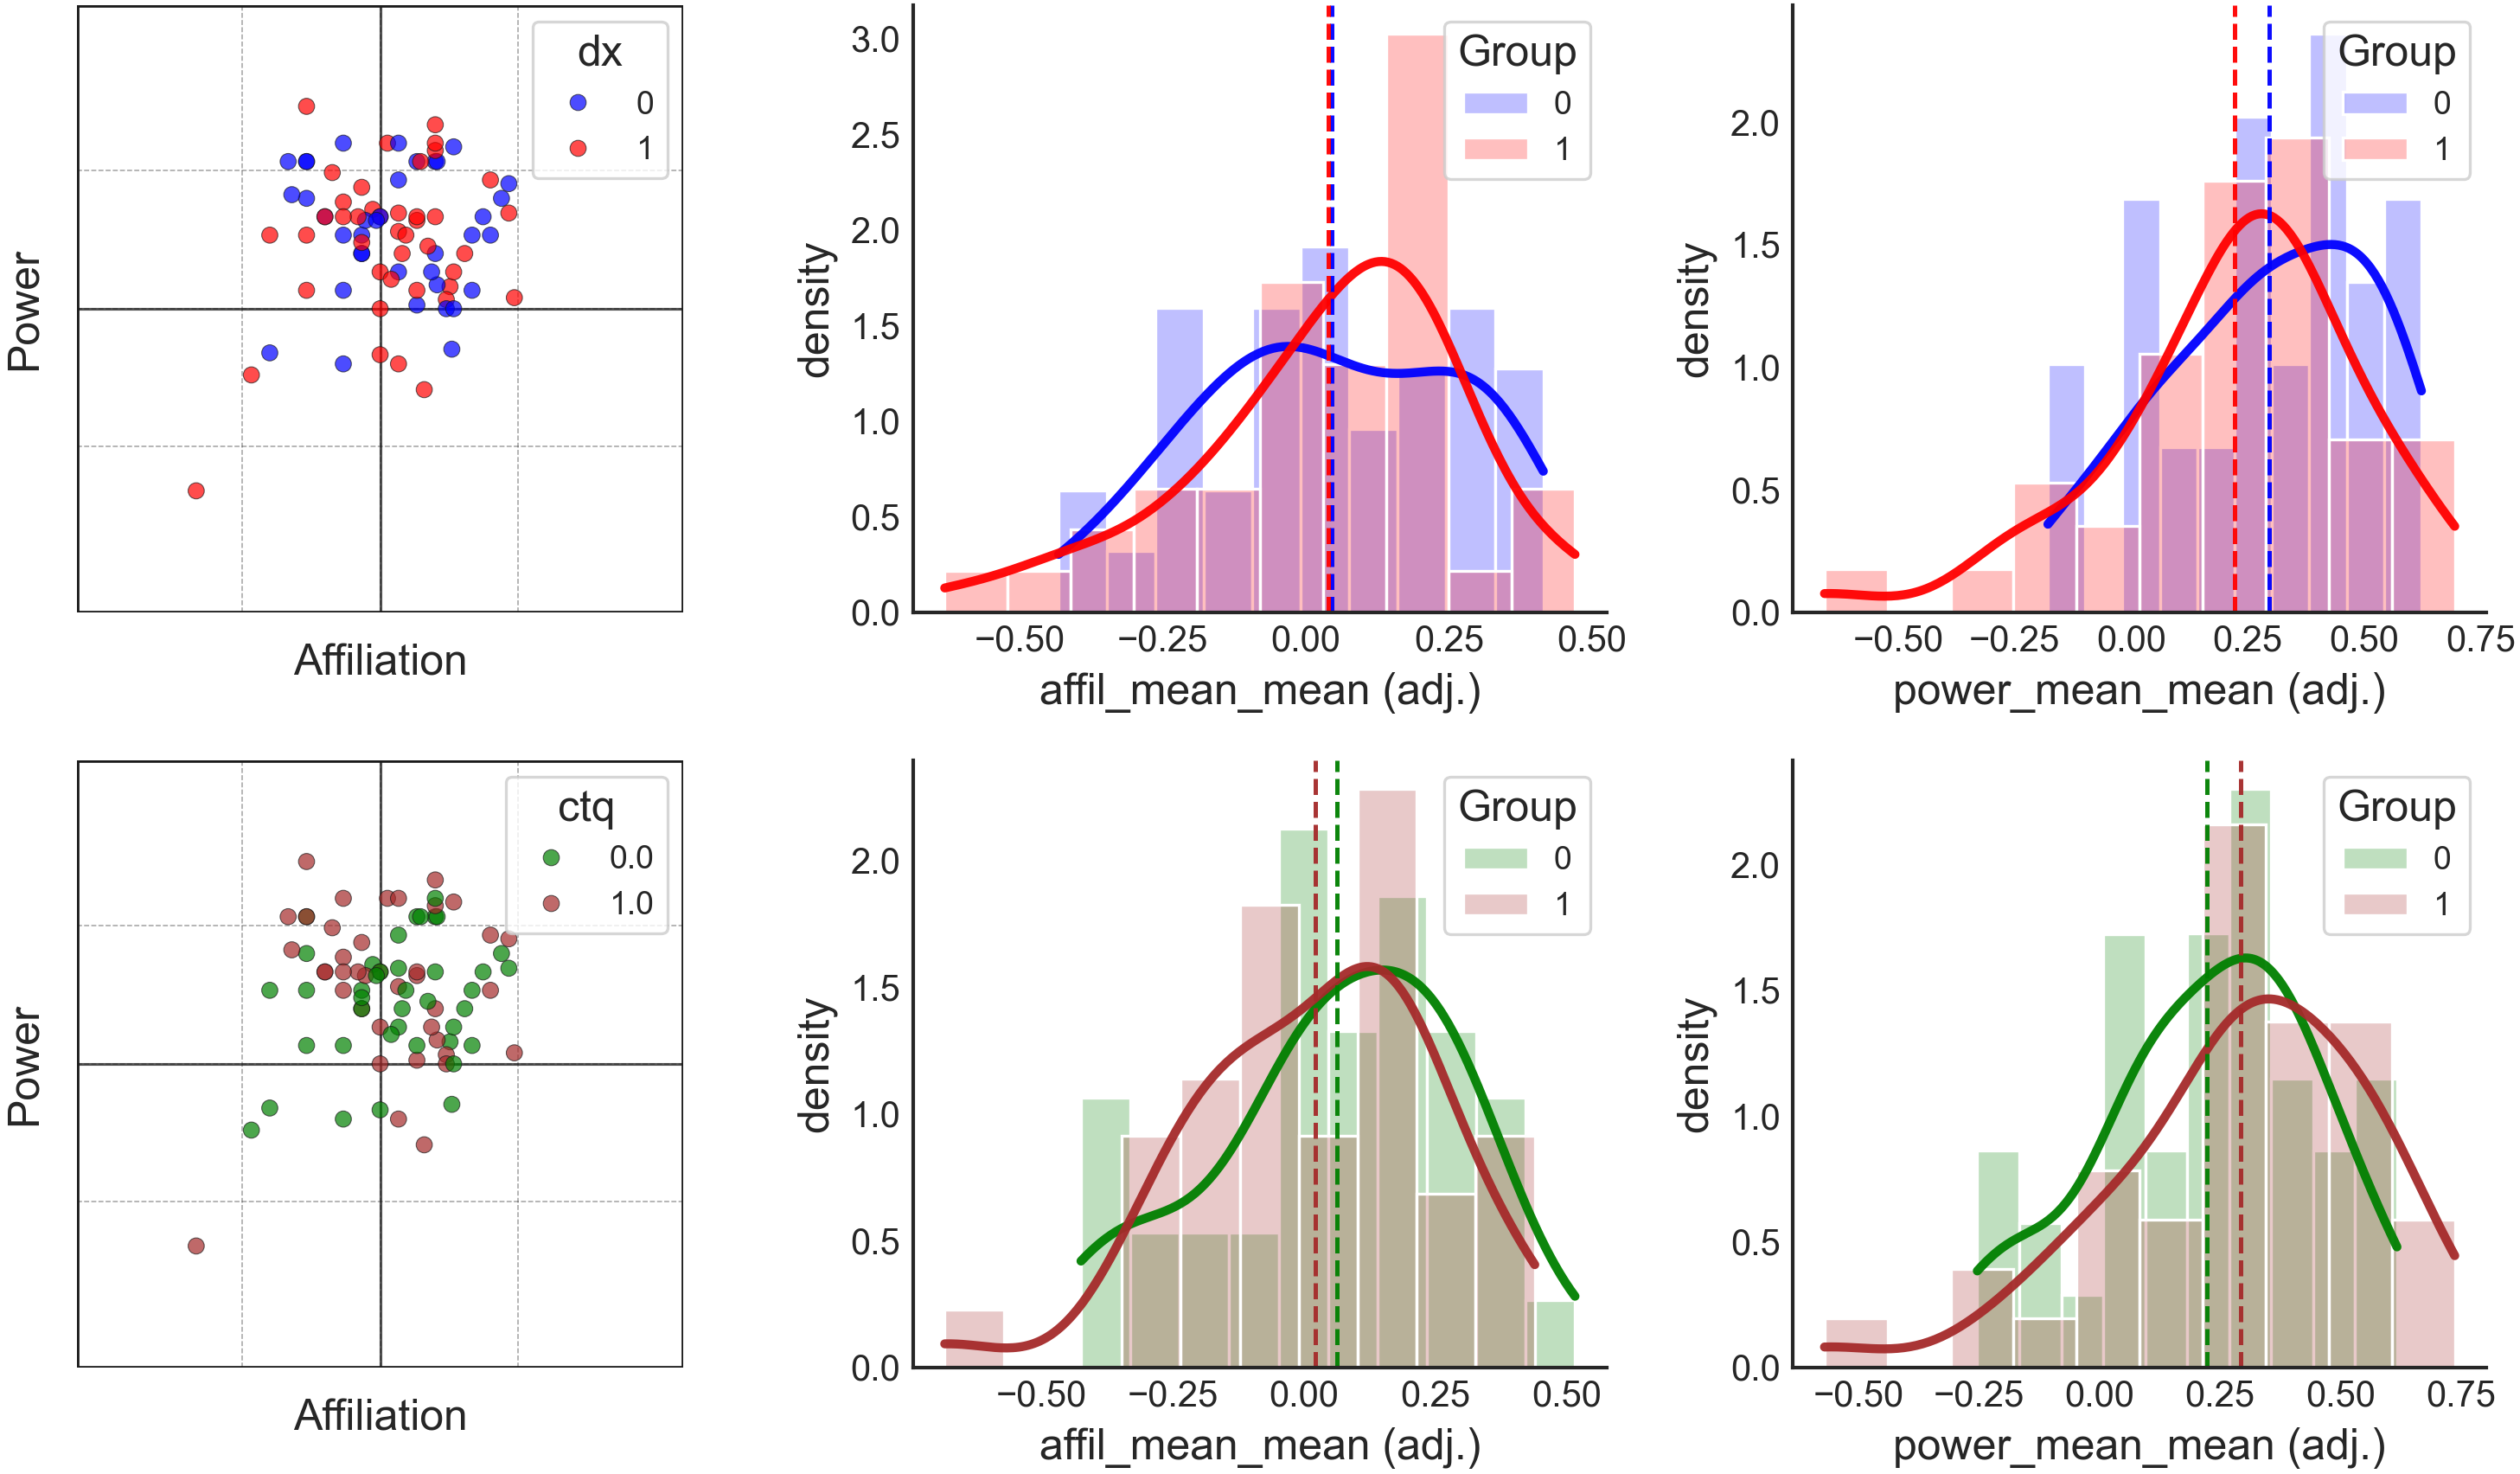

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))

ax = axs[0, 0]
sns.scatterplot(
    x='affil_mean_mean',
    y='power_mean_mean',
    hue='dx',
    data=data,
    palette={0:'blue', 1:'red'},
    alpha=0.7,
    s=20,
    edgecolor='k',
    linewidth=0.25,
    ax=ax
)
plot_social_space(ax=ax, label_fontsize=12, origin_size=0, linewidth=1.5)

covariates = ['age_years', 'sex' ,'ctq_score']
ax = axs[0, 1]
histplot_groups(data, x='affil_mean_mean', covariates=covariates, bins=10, ax=ax)

ax = axs[0, 2]
histplot_groups(data, x='power_mean_mean', covariates=covariates, bins=10, ax=ax);

ax = axs[1, 0]
sns.scatterplot(
    x='affil_mean_mean',
    y='power_mean_mean',
    hue='ctq',
    data=data,
    palette={0:ctq_colors[0], 1:ctq_colors[1]},
    alpha=0.7,
    s=20,
    edgecolor='k',
    linewidth=0.25,
    ax=ax
)
plot_social_space(ax=ax, label_fontsize=12, origin_size=0, linewidth=1.5)

covariates = ['age_years', 'sex' ,'dx']
ax = axs[1, 1]
histplot_groups(data, x='affil_mean_mean', group_col='ctq', covariates=covariates, bins=10, ax=ax)

ax = axs[1, 2]
histplot_groups(data, x='power_mean_mean', group_col='ctq', covariates=covariates, bins=10, ax=ax);

plt.tight_layout()